In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/healthcare_dataset.csv")

In [3]:
df.head()

,Patient_ID,Gender,Age,Medical_Condition,Admission_Date,Admission_Type,Medical_Code,Billing_Amount,Discharge_Date
0,P1001,Male,45,Hypertension,15-01-2026,Urgent,ICD10 I10,4500.0,20-01-2026
1,P1002,Female,32,Pneumonia,16-01-2026,Emergency,ICD10 J18,6700.5,22-01-2026
2,P1003,Male,68,Diabetes Type 2,16-01-2026,Routine,ICD10 E11,3200.0,18-01-2026
3,P1004,Female,55,Asthma,17-01-2026,Emergency,ICD10 J45,5800.0,19-01-2026
4,P1005,Male,29,Fracture,17-01-2026,Urgent,ICD10 S52,8500.0,25-01-2026


In [4]:
df.columns

Index(['Patient_ID', 'Gender', 'Age', 'Medical_Condition', 'Admission_Date',
       'Admission_Type', 'Medical_Code', 'Billing_Amount', 'Discharge_Date'],
      dtype='object')

In [5]:
df.columns

Index(['Patient_ID', 'Gender', 'Age', 'Medical_Condition', 'Admission_Date',
       'Admission_Type', 'Medical_Code', 'Billing_Amount', 'Discharge_Date'],
      dtype='object')

In [6]:
df.dtypes

,0
Patient_ID,object
Gender,object
Age,int64
Medical_Condition,object
Admission_Date,object
Admission_Type,object
Medical_Code,object
Billing_Amount,float64
Discharge_Date,object


In [7]:
df.isnull()

,Patient_ID,Gender,Age,Medical_Condition,Admission_Date,Admission_Type,Medical_Code,Billing_Amount,Discharge_Date
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
495,False,False,False,False,False,False,False,False,False
496,False,False,False,False,False,False,False,False,False
497,False,False,False,False,False,False,False,False,False
498,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

,0
Patient_ID,0
Gender,0
Age,0
Medical_Condition,0
Admission_Date,0
Admission_Type,0
Medical_Code,15
Billing_Amount,0
Discharge_Date,0


In [13]:
df["Admission_Date"] = pd.to_datetime(df["Admission_Date"], dayfirst=True)
df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"], dayfirst=True)

In [14]:
df["stay Duration"] = (
    df["Discharge_Date"] - df["Admission_Date"]
).dt.days
df.head()

,Patient_ID,Gender,Age,Medical_Condition,Admission_Date,Admission_Type,Medical_Code,Billing_Amount,Discharge_Date,stay Duration
0,P1001,Male,45,Hypertension,2026-01-15,Urgent,ICD10 I10,4500.0,2026-01-20,5
1,P1002,Female,32,Pneumonia,2026-01-16,Emergency,ICD10 J18,6700.5,2026-01-22,6
2,P1003,Male,68,Diabetes Type 2,2026-01-16,Routine,ICD10 E11,3200.0,2026-01-18,2
3,P1004,Female,55,Asthma,2026-01-17,Emergency,ICD10 J45,5800.0,2026-01-19,2
4,P1005,Male,29,Fracture,2026-01-17,Urgent,ICD10 S52,8500.0,2026-01-25,8


In [16]:
billing = df.groupby(["Medical_Condition"])["Billing_Amount"].sum()

In [17]:
data = df.groupby(
    ["Medical_Condition"]
)["Billing_Amount"].mean()

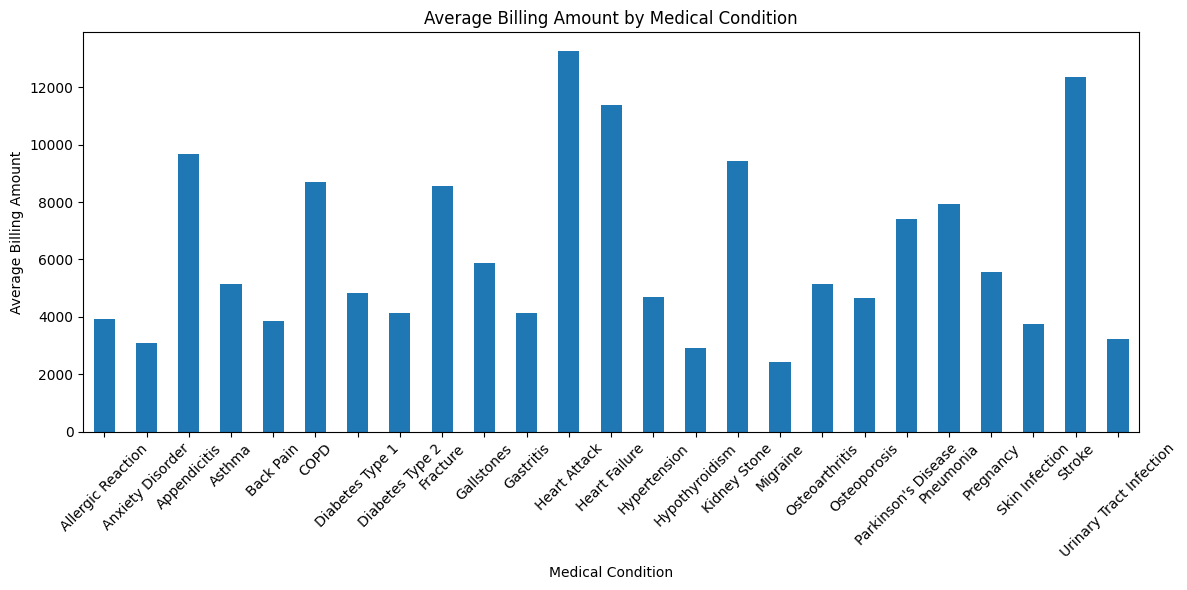

In [19]:
data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Billing Amount by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Average Billing Amount")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

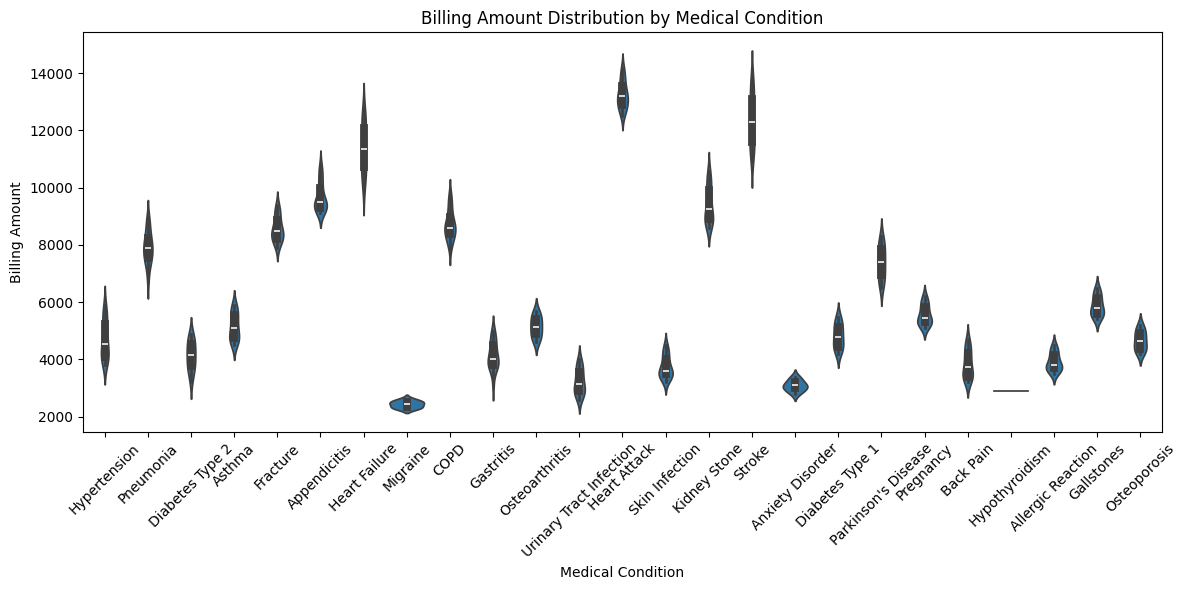

In [21]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x="Medical_Condition",
    y="Billing_Amount"
)

plt.title("Billing Amount Distribution by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Billing Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

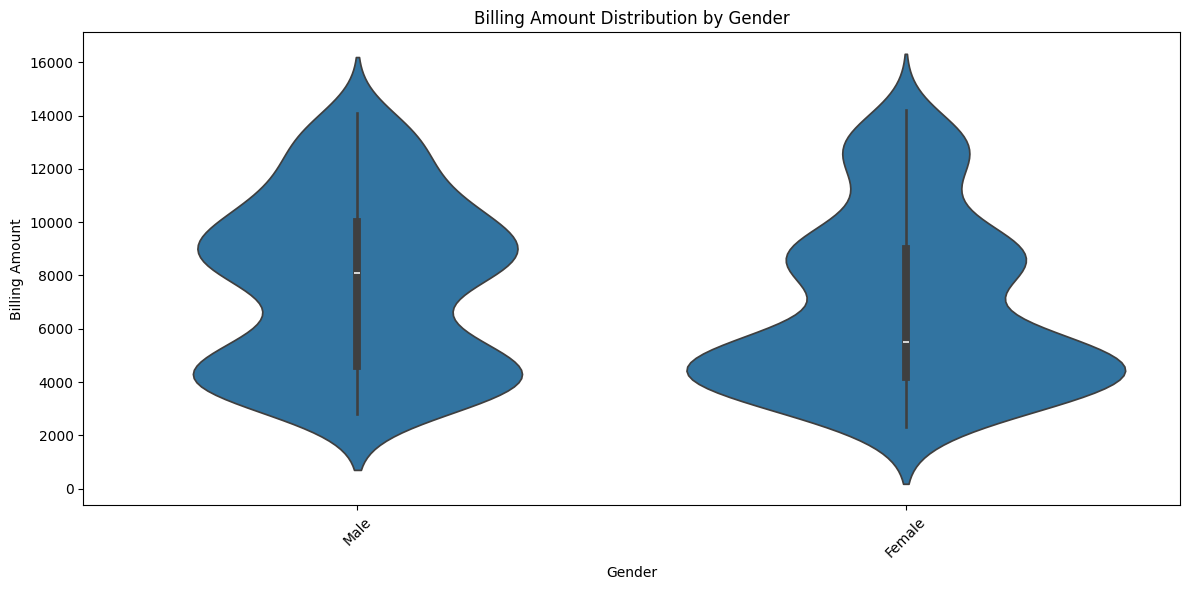

In [23]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x="Gender",
    y="Billing_Amount"
)

plt.title("Billing Amount Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Billing Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
df['Admission'] = df['Admission_Date'].dt.month

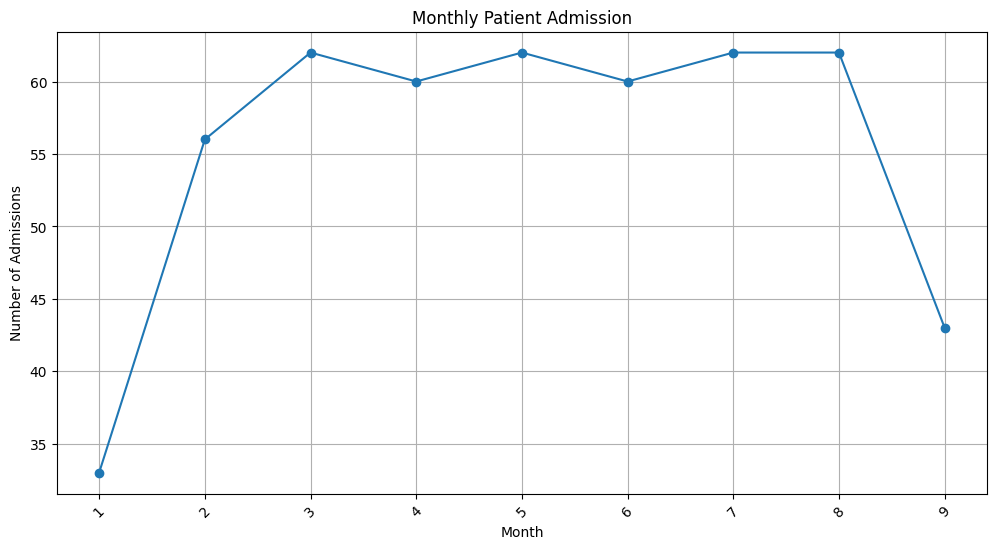

In [26]:
plt.figure(figsize=(12,6))
Monthly_Admission = df.groupby('Admission').size()
Monthly_Admission.plot(kind="line",marker="o")

plt.title("Monthly Patient Admission")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.grid()


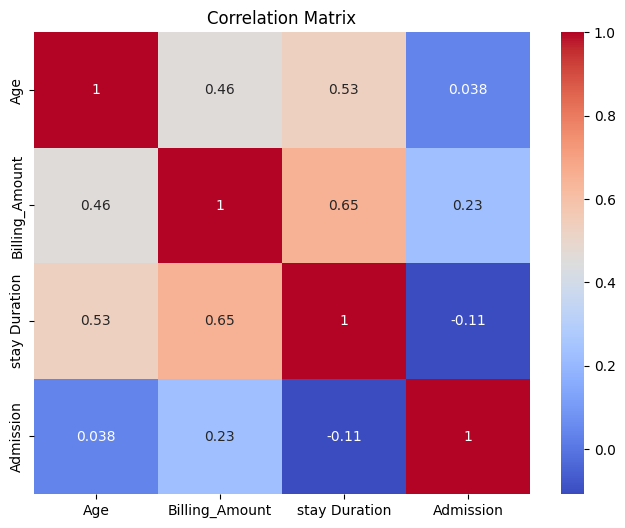

In [28]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()